Question 4 Demonstrate that EM is a local search algorithm susceptible to local optima.
Task:
1) Generate a 2D dataset with four highly overlapping clusters.
2) Run the EM algorithm 10 times using init_params='random'. Record the final converged log-likelihood for each run.
3) Run the algorithm 10 times using init_params='kmeans'.
4) Evaluation: Create a boxplot comparing the final log-likelihoods of the 'random' vs. 'kmeans' initializations.
5) Question: Why does K-means initialization generally lead to more stable results than random initialization in GMMs?

In [29]:
from sklearn.mixture import GaussianMixture
import numpy as np
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=2)

random_ll = []
kmeans_ll = []

for _ in range(10):
    gmm_r = GaussianMixture(n_components=4, init_params='random')
    gmm_r.fit(X)
    random_ll.append(gmm_r.lower_bound_)

    gmm_k = GaussianMixture(n_components=4, init_params='kmeans')
    gmm_k.fit(X)
    kmeans_ll.append(gmm_k.lower_bound_)

/var/folders/z3/tjldnlcd4m5gt089s0_wpd9m0000gn/T/ipykernel_28525/1152166874.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([random_ll, kmeans_ll], labels=['Random','KMeans'])


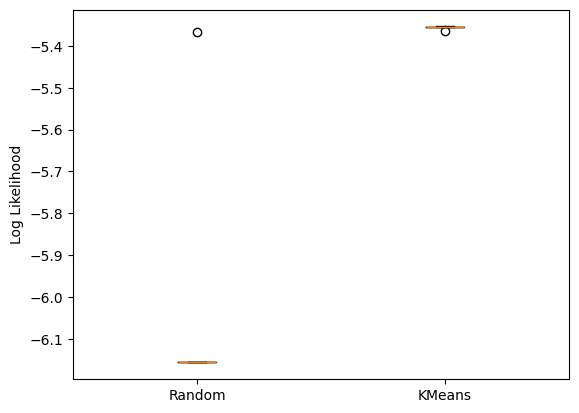

In [30]:
plt.boxplot([random_ll, kmeans_ll], labels=['Random','KMeans'])
plt.ylabel("Log Likelihood")
plt.show()